# Segmentation — Evaluation

YOLO11-seg / SAM 2 / Grounded-SAM の結果を横断比較する。

- YOLO11-seg / Grounded-SAM: mask AP (pycocotools segm)
- SAM 2: best-match IoU + Recall@50（クラスラベルなしのため別指標）

In [2]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image

PROJECT_ROOT = Path("/workspace")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [3]:
CHECKPOINT_ROOT = Path("/workspace/checkpoints/segmentation")

# mask AP モデル
AP_MODEL_RUNS: dict[str, Path] = {
    "yolo11_seg":    CHECKPOINT_ROOT / "yolo11_seg"    / "yolo11_seg_coco",
    "grounded_sam":  CHECKPOINT_ROOT / "grounded_sam"  / "grounded_sam_coco",
}

# SAM 2（別指標）
SAM2_RUN: Path = CHECKPOINT_ROOT / "sam2" / "sam2_coco"

VAL_ANN_PATH  = Path("/workspace/data/coco/annotations/instances_val2017.json")
VAL_IMAGE_ROOT = Path("/workspace/data/coco/val2017")

In [4]:
def load_json(path: Path) -> dict | list:
    return json.loads(path.read_text()) if path.exists() else {}

def load_dataframe(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

## 1. Overview — mask AP 比較（YOLO11-seg / Grounded-SAM）

In [5]:
rows = []
for model_name, run_root in AP_MODEL_RUNS.items():
    summary     = load_json(run_root / "experiment_summary.json")
    test_summary = load_json(run_root / "best_test_results" / "summary.json")
    if not summary:
        continue
    rows.append({
        "model":           model_name,
        "mode":            summary.get("mode"),
        "mask_ap50":       summary.get("test_mask_ap50"),
        "mask_ap":         summary.get("test_mask_ap"),
        "mask_ap_small":   test_summary.get("mask_ap_small"),
        "mask_ap_medium":  test_summary.get("mask_ap_medium"),
        "mask_ap_large":   test_summary.get("mask_ap_large"),
        "checkpoint":      summary.get("best_checkpoint_path"),
    })

overview_df = pd.DataFrame(rows)
display(overview_df)

,model,mode,mask_ap50,mask_ap,mask_ap_small,mask_ap_medium,mask_ap_large,checkpoint
0,yolo11_seg,pretrained,0.617359,0.391551,0.155217,0.424133,0.607718,yolo11s-seg.pt
1,grounded_sam,zeroshot,0.645546,0.448464,0.241723,0.505363,0.621252,/workspace/checkpoints/segmentation/sam2/sam2....


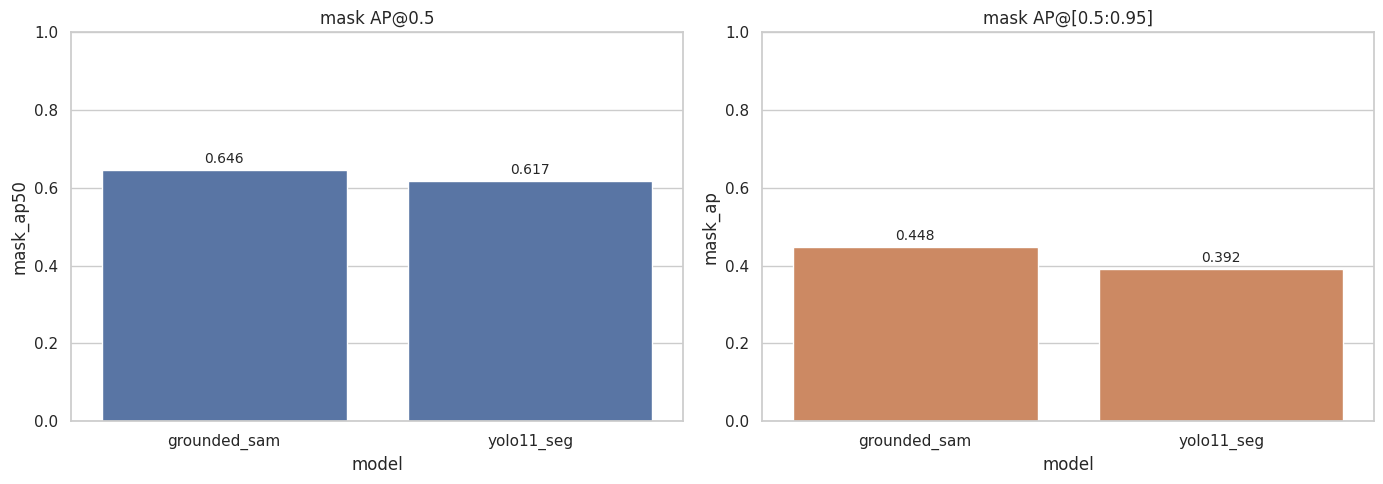

In [6]:
if len(overview_df):
    plot_df = overview_df.dropna(subset=["mask_ap50", "mask_ap"]).sort_values("mask_ap50", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=plot_df, x="model", y="mask_ap50", ax=axes[0], color="#4C72B0")
    axes[0].set_title("mask AP@0.5")
    axes[0].set_ylim(0, 1)
    for bar in axes[0].patches:
        h = bar.get_height()
        if h == h:
            axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                         f"{h:.3f}", ha="center", va="bottom", fontsize=10)

    sns.barplot(data=plot_df, x="model", y="mask_ap", ax=axes[1], color="#DD8452")
    axes[1].set_title("mask AP@[0.5:0.95]")
    axes[1].set_ylim(0, 1)
    for bar in axes[1].patches:
        h = bar.get_height()
        if h == h:
            axes[1].text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                         f"{h:.3f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()

## 2. SAM 2 — Recall@50 / mean best-match IoU

,model,mode,recall_50,mean_best_iou,n_gt_total,n_matched
0,sam2,zeroshot,0.598744,0.537082,3504,2098


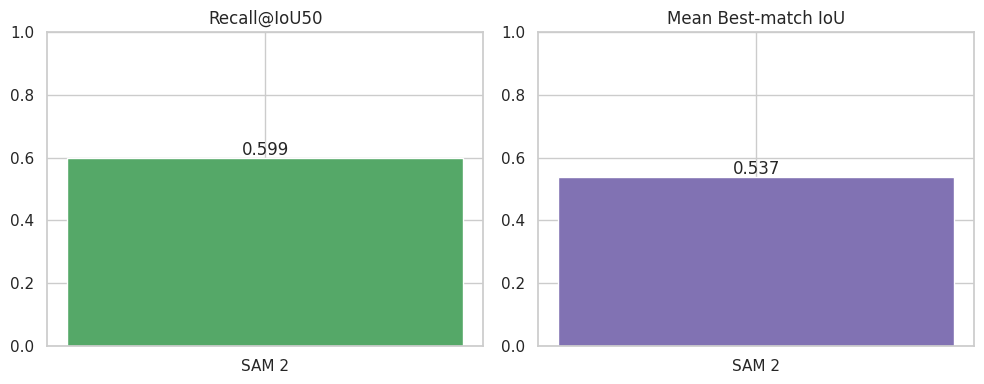

In [7]:
sam2_summary = load_json(SAM2_RUN / "experiment_summary.json")
sam2_test    = load_json(SAM2_RUN / "best_test_results" / "summary.json")

if sam2_summary:
    sam2_df = pd.DataFrame([{
        "model":          "sam2",
        "mode":           sam2_summary.get("mode"),
        "recall_50":      sam2_summary.get("test_recall_50"),
        "mean_best_iou":  sam2_summary.get("test_mean_best_iou"),
        "n_gt_total":     sam2_test.get("n_gt_total"),
        "n_matched":      sam2_test.get("n_matched"),
    }])
    display(sam2_df)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(["SAM 2"], [sam2_summary.get("test_recall_50", 0)], color="#55A868")
    axes[0].set_title("Recall@IoU50")
    axes[0].set_ylim(0, 1)
    axes[0].text(0, sam2_summary.get("test_recall_50", 0) + 0.01,
                 f"{sam2_summary.get('test_recall_50', 0):.3f}", ha="center", fontsize=12)

    axes[1].bar(["SAM 2"], [sam2_summary.get("test_mean_best_iou", 0)], color="#8172B3")
    axes[1].set_title("Mean Best-match IoU")
    axes[1].set_ylim(0, 1)
    axes[1].text(0, sam2_summary.get("test_mean_best_iou", 0) + 0.01,
                 f"{sam2_summary.get('test_mean_best_iou', 0):.3f}", ha="center", fontsize=12)

    plt.tight_layout()
    plt.show()
else:
    print("SAM 2 results not found.")

## 3. Scale 別 mask AP (small / medium / large)

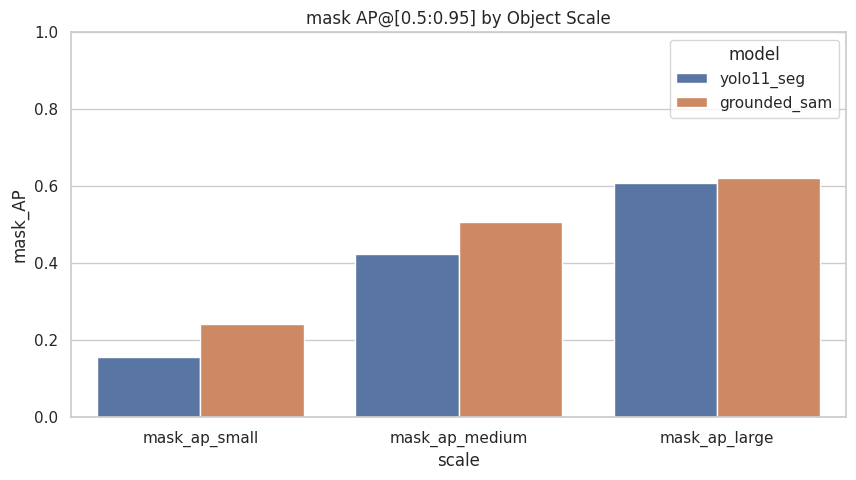

In [8]:
scale_cols = ["model", "mask_ap_small", "mask_ap_medium", "mask_ap_large"]
scale_df = overview_df[scale_cols].dropna()

if len(scale_df):
    melted = scale_df.melt(id_vars="model", var_name="scale", value_name="mask_AP")
    plt.figure(figsize=(10, 5))
    sns.barplot(data=melted, x="scale", y="mask_AP", hue="model")
    plt.title("mask AP@[0.5:0.95] by Object Scale")
    plt.ylim(0, 1)
    plt.show()
else:
    print("No scale data available yet.")

## 4. Per-category mask AP

In [9]:
cat_frames = []
for model_name, run_root in AP_MODEL_RUNS.items():
    df = load_dataframe(run_root / "best_test_results" / "per_category_ap.csv")
    if len(df):
        df["model"] = model_name
        cat_frames.append(df)

cat_df = pd.concat(cat_frames, ignore_index=True) if cat_frames else pd.DataFrame()
display(cat_df.head(20) if len(cat_df) else "No per-category data yet.")

,category_id,name,mask_ap,mask_ap50,model
0,1,person,0.412444,0.749818,yolo11_seg
1,2,bicycle,0.150297,0.373110,yolo11_seg
2,3,car,0.315300,0.607603,yolo11_seg
3,4,motorcycle,0.457385,0.866928,yolo11_seg
4,5,airplane,0.501298,0.831683,yolo11_seg
5,6,bus,0.562790,0.821388,yolo11_seg
6,7,train,0.585330,0.750990,yolo11_seg
7,8,truck,0.226435,0.384536,yolo11_seg
8,9,boat,0.104945,0.337718,yolo11_seg
9,10,traffic light,0.136520,0.302315,yolo11_seg


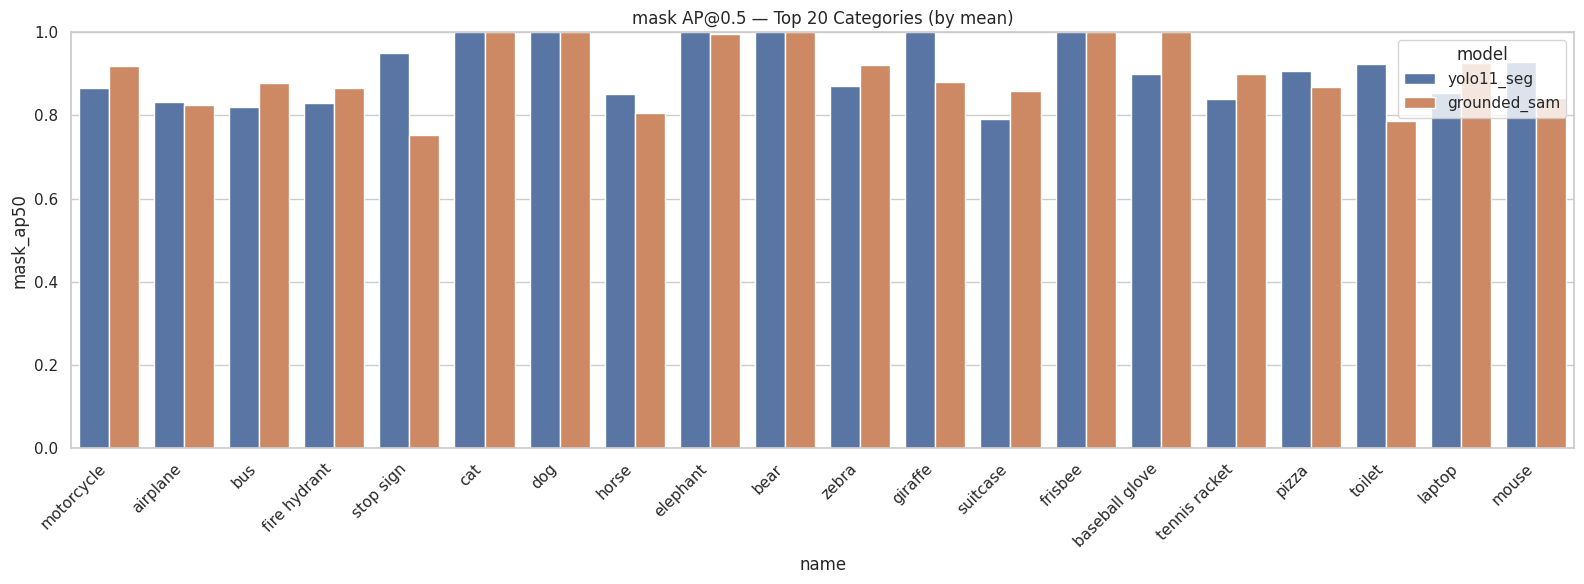

In [10]:
if len(cat_df):
    top_cats = (
        cat_df.groupby("name")["mask_ap50"].mean()
        .sort_values(ascending=False)
        .head(20)
        .index.tolist()
    )
    plot_cat_df = cat_df[cat_df["name"].isin(top_cats)]

    plt.figure(figsize=(16, 6))
    sns.barplot(data=plot_cat_df, x="name", y="mask_ap50", hue="model")
    plt.title("mask AP@0.5 — Top 20 Categories (by mean)")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

## 5. SAM 2 — per-image 予測マスク数分布

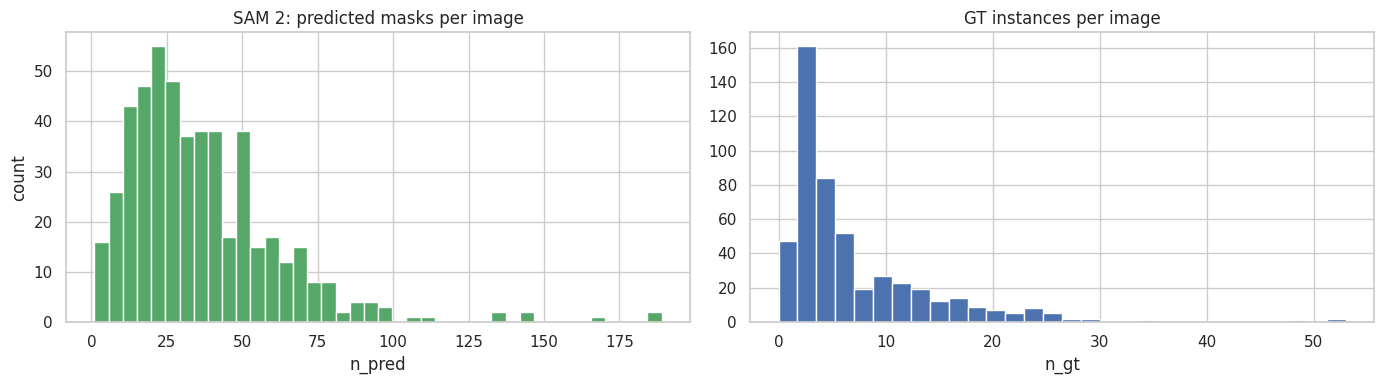

mean n_pred : 36.6
mean n_gt   : 7.0


In [11]:
sam2_preds_df = load_dataframe(SAM2_RUN / "best_test_results" / "predictions.csv")

if len(sam2_preds_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(sam2_preds_df["n_pred"], bins=40, color="#55A868", edgecolor="white")
    axes[0].set_title("SAM 2: predicted masks per image")
    axes[0].set_xlabel("n_pred")
    axes[0].set_ylabel("count")

    axes[1].hist(sam2_preds_df["n_gt"], bins=30, color="#4C72B0", edgecolor="white")
    axes[1].set_title("GT instances per image")
    axes[1].set_xlabel("n_gt")

    plt.tight_layout()
    plt.show()

    print(f"mean n_pred : {sam2_preds_df['n_pred'].mean():.1f}")
    print(f"mean n_gt   : {sam2_preds_df['n_gt'].mean():.1f}")
else:
    print("SAM 2 predictions.csv not found.")

## 6. Supervised vs Zero-shot まとめ

In [12]:
summary_rows = []
for model_name, run_root in AP_MODEL_RUNS.items():
    s = load_json(run_root / "experiment_summary.json")
    if s:
        summary_rows.append({
            "model":       model_name,
            "mode":        s.get("mode"),
            "metric":      "mask_ap50",
            "value":       s.get("test_mask_ap50"),
        })

if sam2_summary:
    summary_rows.append({
        "model":   "sam2",
        "mode":    sam2_summary.get("mode"),
        "metric":  "recall@50",
        "value":   sam2_summary.get("test_recall_50"),
    })

final_df = pd.DataFrame(summary_rows)
display(final_df.sort_values("value", ascending=False).reset_index(drop=True))

print()
print("Note: SAM 2 の metric は recall@50（クラスラベルなし）のため mask AP とは直接比較不可")

,model,mode,metric,value
0,grounded_sam,zeroshot,mask_ap50,0.645546
1,yolo11_seg,pretrained,mask_ap50,0.617359
2,sam2,zeroshot,recall@50,0.598744



Note: SAM 2 の metric は recall@50（クラスラベルなし）のため mask AP とは直接比較不可


## 7. マスク可視化 — ランダムサンプル比較

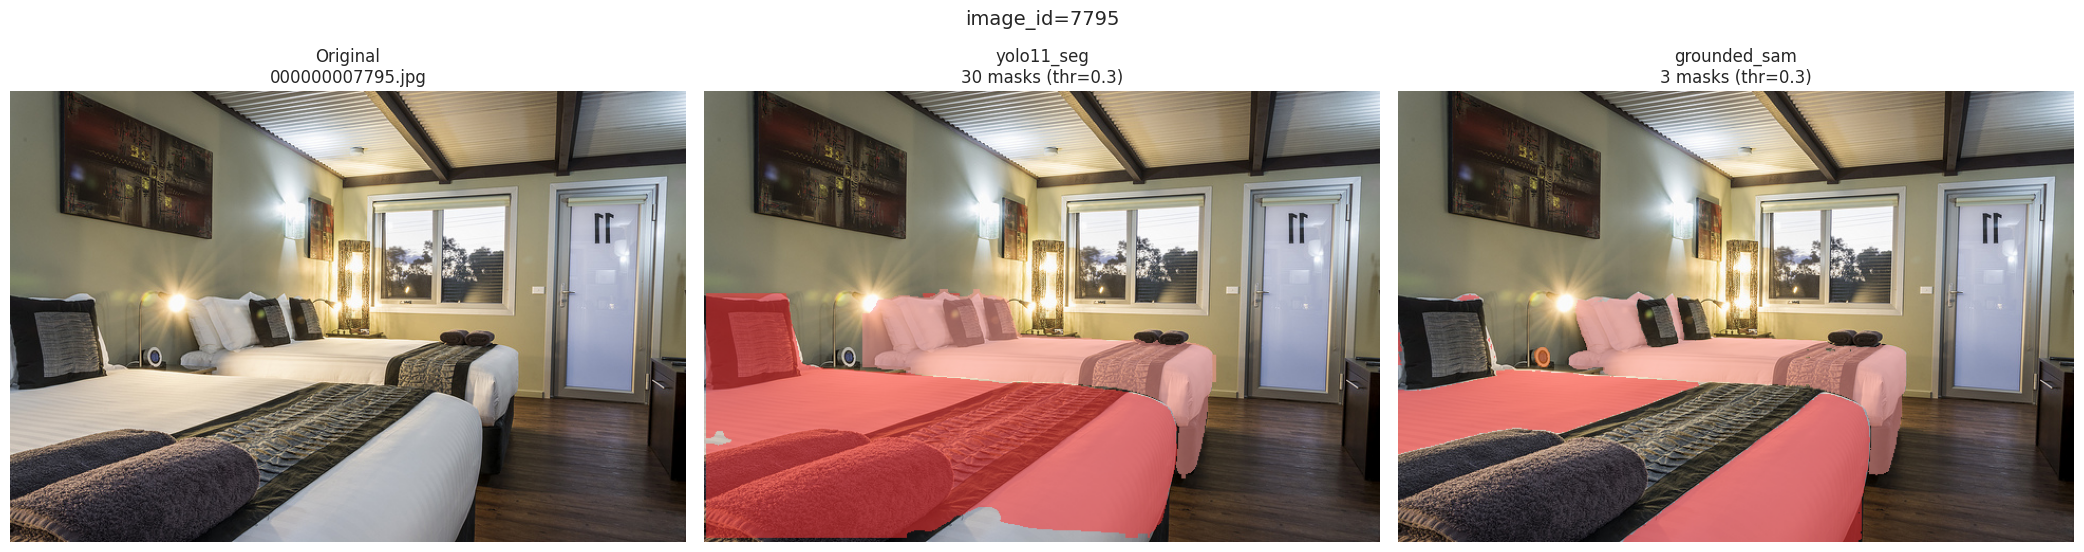

In [13]:
from pycocotools import mask as mask_util

SCORE_THRESHOLD = 0.3
COLORS = [
    (255, 56, 56), (255, 157, 151), (255, 112, 31), (255, 178, 29),
    (207, 210, 49), (72, 249, 10), (146, 204, 23), (61, 219, 134),
    (26, 147, 52), (0, 212, 187), (44, 153, 168), (0, 194, 255),
    (52, 69, 147), (100, 115, 255), (0, 24, 236), (132, 56, 255),
    (82, 0, 133), (203, 56, 255), (255, 149, 200), (255, 55, 199),
]


def overlay_masks(image_pil: Image.Image, dt_results: list[dict], score_threshold: float) -> Image.Image:
    """Overlay COCO-format segmentation masks on image."""
    img_np = np.array(image_pil.convert("RGB")).copy()
    overlay = img_np.copy()

    filtered = [d for d in dt_results if d.get("score", 1.0) >= score_threshold]
    filtered = sorted(filtered, key=lambda d: d.get("score", 0.0), reverse=True)

    for i, det in enumerate(filtered):
        seg = det["segmentation"]
        if isinstance(seg["counts"], str):
            seg = {"counts": seg["counts"].encode("utf-8"), "size": seg["size"]}
        binary_mask = mask_util.decode(seg).astype(bool)
        color = COLORS[i % len(COLORS)]
        overlay[binary_mask] = color

    blended = (img_np * 0.45 + overlay * 0.55).clip(0, 255).astype(np.uint8)
    return Image.fromarray(blended)


ann_data = load_json(VAL_ANN_PATH)
image_info_by_id = {img["id"]: img for img in ann_data.get("images", [])}

# 各モデルの predictions をロード
preds_by_model: dict[str, list[dict]] = {}
candidate_ids: set[int] = set()

for model_name, run_root in AP_MODEL_RUNS.items():
    preds = load_json(run_root / "best_test_results" / "predictions.json")
    preds_by_model[model_name] = preds if isinstance(preds, list) else []
    candidate_ids.update(d["image_id"] for d in preds_by_model[model_name])

if not candidate_ids:
    print("No predictions found.")
else:
    selected_id = random.choice(sorted(candidate_ids))
    image_info = image_info_by_id[selected_id]
    base_image = Image.open(VAL_IMAGE_ROOT / image_info["file_name"]).convert("RGB")

    model_names = list(AP_MODEL_RUNS.keys())
    fig, axes = plt.subplots(1, len(model_names) + 1, figsize=(7 * (len(model_names) + 1), 6))

    axes[0].imshow(base_image)
    axes[0].set_title(f"Original\n{image_info['file_name']}")
    axes[0].axis("off")

    for ax, model_name in zip(axes[1:], model_names):
        preds = [d for d in preds_by_model[model_name] if d["image_id"] == selected_id]
        vis = overlay_masks(base_image, preds, SCORE_THRESHOLD)
        ax.imshow(vis)
        ax.set_title(f"{model_name}\n{len(preds)} masks (thr={SCORE_THRESHOLD})")
        ax.axis("off")

    plt.suptitle(f"image_id={selected_id}", fontsize=14)
    plt.tight_layout()
    plt.show()